<a href="https://colab.research.google.com/github/mzaheen610/ExpenseTracker/blob/main/MultipleLinearRegression_50startups_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files



In [5]:
upload = files.upload()

Saving 50_Startups.csv to 50_Startups.csv


In [10]:
#Loading starup data into Dataframe
df = pd.read_csv('50_Startups.csv')
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [12]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


<Axes: >

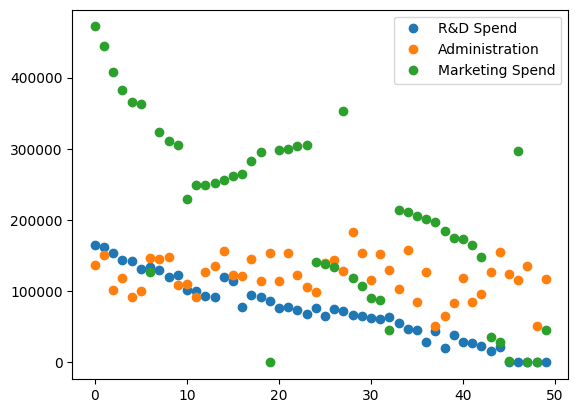

In [16]:
X = df.drop(['Profit','State'], axis=1)
y = df['Profit']
X.plot(style='o')

Splitting dataset for training and testing.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=0)

regressor = LinearRegression()
regressor.fit(X_train, Y_train)

print(regressor.coef_)
print(regressor.intercept_)

mse = mean_squared_error(Y_test, y_prediction)
r2 = r2_score(Y_test, y_prediction)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

[0.77884104 0.0293919  0.03471025]
42989.00816508665
Mean Squared Error: 77506468.16885428
R-squared: 0.9393955917820569


In [19]:
#Making predicitions using the test data
y_prediction = regressor.predict(X_test)

df = pd.DataFrame({'Actual': Y_test, 'Predicted': y_prediction})
df


,Actual,Predicted
28,103282.38,103901.896970
11,144259.40,132763.059931
10,146121.95,133567.903700
41,77798.83,72911.789767
2,191050.39,179627.925672
27,105008.31,115166.648648
38,81229.06,67113.576906
31,97483.56,98154.806868
22,110352.25,114756.115552
4,166187.94,169064.014088


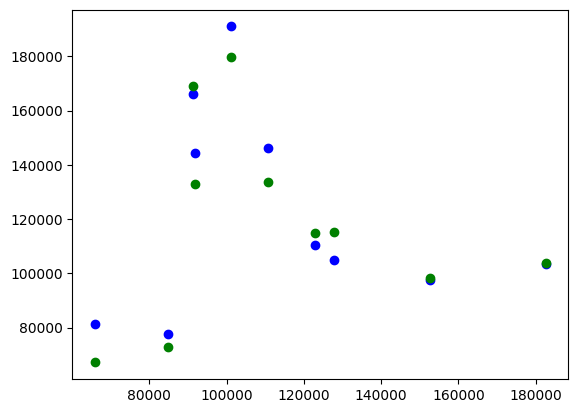

In [34]:
plt.scatter(X_test['Administration'], Y_test, color='blue')
plt.scatter(X_test['Administration'], y_prediction, color='green')
plt.show()

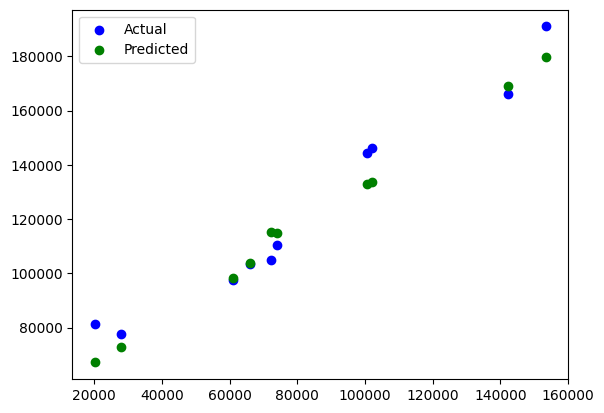

In [42]:
plt.scatter(X_test['R&D Spend'], Y_test, color='blue', )
plt.scatter(X_test['R&D Spend'], y_prediction, color='green')
plt.legend(['Actual', 'Predicted'])
plt.show()